<a href="https://colab.research.google.com/github/Debnath-Goutam/MS-DACS/blob/master/MS_DACS_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics
!pip install torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 7.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os, random
from glob import glob
import pickle
import torch, torchvision
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

from torchvision.transforms import functional as F
import torch.nn.functional as nnF
from multiprocessing.pool import ThreadPool
from sklearn.cluster import KMeans
from multiprocessing import Pool, cpu_count
from tqdm import tqdm
from ultralytics import YOLO
from collections import defaultdict
import cv2

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
os.cpu_count()

# Test (1 image)

In [ ]:
def collect_img_paths(root, modality):
    paths = []
    set_dirs = sorted(glob(os.path.join(root, 'set*')))
    for s in set_dirs:
        V_dirs = sorted(glob(os.path.join(s, 'V*')))
        if V_dirs:
            for v in V_dirs:
                img_dir = os.path.join(v, modality)
                imgs = sorted(glob(os.path.join(img_dir, '*.jpg')))
                paths.extend(imgs)
        else:
            img_dir = os.path.join(s, modality)
            imgs = sorted(glob(os.path.join(img_dir, '*.jpg')))
            paths.extend(imgs)
    return paths

In [ ]:
def make_paired_dataset(root, img_size=(640, 640), batch_size=32):
    visible_paths_full = collect_img_paths(root, 'visible')
    lwir_paths_full = collect_img_paths(root, 'lwir')

    # Create dictionaries mapping a unique key (without modality) to the full path
    visible_map = {}
    for p in visible_paths_full:
        key = p.replace('/visible/', '/') # Remove modality part for common key
        visible_map[key] = p

    lwir_map = {}
    for p in lwir_paths_full:
        key = p.replace('/lwir/', '/') # Remove modality part for common key
        lwir_map[key] = p

    # Find common keys (images present in both modalities)
    common_keys = sorted(list(set(visible_map.keys()).intersection(set(lwir_map.keys()))))

    # Reconstruct the paired lists using only common keys
    visible_paths_filtered = [visible_map[key] for key in common_keys]
    lwir_paths_filtered = [lwir_map[key] for key in common_keys]

    # Assert that the filtered lists have the same length
    if len(visible_paths_filtered) != len(lwir_paths_filtered):
        raise ValueError("Filtered visible and LWIR paths do not have the same length.")

    paths = tf.data.Dataset.from_tensor_slices((visible_paths_filtered, lwir_paths_filtered))

    def _load_pairs(vis_path, ir_path):
        vis = tf.io.read_file(vis_path)
        vis = tf.image.decode_jpeg(vis, channels=3)
        vis = tf.image.resize(vis, img_size)
        vis = tf.cast(vis, tf.uint8)

        ir = tf.io.read_file(ir_path)
        ir = tf.image.decode_jpeg(ir, channels=1)
        ir = tf.image.resize(ir, img_size)
        ir = tf.repeat(ir, repeats=3, axis=-1)
        ir = tf.cast(ir, tf.uint8)

        return (vis, ir), vis_path

    dataset = paths.map(_load_pairs, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size=batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
root = '/content/drive/MyDrive/MS-DACS Thesis/KAIST dataset'

#visible_dataset = make_dataset(root, modality='visible')
#ir_dataset = make_dataset(root, modality='lwir')

paired_dataset = make_paired_dataset(root)

for (vis_batch, ir_batch), paths in paired_dataset.take(1):
    print('Visible:', vis_batch.shape)
    print('IR:', ir_batch.shape)
    print('First path:', paths[0].numpy().decode())

In [ ]:
visible_paths = collect_img_paths(root, 'visible')
lwir_paths = collect_img_paths(root, 'lwir')

print(f"Number of visible image paths: {len(visible_paths)}")
print(f"Number of LWIR image paths: {len(lwir_paths)}")

# Convert to sets for easier comparison
visible_set = set(visible_paths)
lwir_set = set(lwir_paths)

# Find paths that are in visible but not in lwir
missing_in_lwir = visible_set - lwir_set
print(f"\nPaths in visible but not in lwir: {len(missing_in_lwir)} files")
if missing_in_lwir:
    for path in list(missing_in_lwir)[:5]: # Print first 5 discrepancies
        print(path)

# Find paths that are in lwir but not in visible
missing_in_visible = lwir_set - visible_set
print(f"\nPaths in lwir but not in visible: {len(missing_in_visible)} files")
if missing_in_visible:
    for path in list(missing_in_visible)[:5]: # Print first 5 discrepancies
        print(path)


In [ ]:
YOLO_model = YOLO("yolov8n.pt")

In [ ]:
for sample in paired_dataset.take(39):
  (rgb, ir), label = sample

rgb_np = rgb.numpy()
ir_np = ir.numpy()

print(rgb_np.shape)
print(rgb_np.dtype)

In [ ]:
results = YOLO_model([image for image in rgb_np])

results[31].show()

In [ ]:
result = results[31]
boxes = result.boxes

for i in range(len(boxes)):
  box = boxes[i]

  coords = box.xyxy[0].cpu().numpy()

  conf = box.conf[0].item()

  cls = int(box.cls[0].item())

  print(f"Detection {i}:")
  print("Class ID:", cls)
  print("Confidence:", conf)
  print("Box:", coords)
  print("-" * 30)

In [ ]:
person_boxes = []

for i in range(len(boxes)):
    box = boxes[i]
    coords = box.xyxy[0].cpu().numpy()
    conf = box.conf[0].item()
    cls = int(box.cls[0].item())

    if cls == 0:
        person_boxes.append((coords, conf))

print(len(person_boxes))

In [ ]:
coords, conf = person_boxes[0]

x1, y1, x2, y2 = map(int, coords)

ir_vis = ir_np[31].copy()

if len(ir_vis.shape) == 2:
  ir_vis = cv2.cvtColor(ir_vis, cv2.COLOR_GRAY2BGR)

cv2.rectangle(ir_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.figure(figsize=(6,6))
plt.imshow(ir_vis)
plt.title("IR Image with Pedestrian Box")
plt.axis("off")

In [ ]:
coords, conf = person_boxes[0]
x1, y1, x2, y2 = map(int, coords)

rgb_crop = rgb_np[31][y1:y2, x1:x2]
ir_crop = ir_np[31][y1:y2, x1:x2]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_crop)
plt.title("RGB Pedestrian")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ir_crop, cmap='gray')
plt.title("IR Pedestrian")
plt.axis("off")

In [ ]:
coords, conf = person_boxes[0]
x1, y1, x2, y2 = map(int, coords)

h, w, _ = rgb_np[31].shape

pad = 20

x1_exp = max(0, x1 - pad)
x2_exp = min(w, x2 + pad)

y1_exp = max(0, y1 - pad)
y2_exp = min(h, y2 + pad)

In [ ]:
rgb_expanded = rgb_np[31][y1_exp:y2_exp, x1_exp:x2_exp]
ir_expanded = ir_np[31][y1_exp:y2_exp, x1_exp:x2_exp]

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_expanded)
plt.title("RGB Expanded Region")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ir_expanded, cmap='gray')
plt.title("IR Expanded Region")
plt.axis("off")

In [ ]:
mask = np.ones(rgb_expanded.shape[:2], dtype=np.uint8)

px1 = x1 - x1_exp
px2 = x2 - x1_exp
py1 = y1 - y1_exp
py2 = y2 - y1_exp

mask[py1:py2, px1:px2] = 0

In [ ]:
rgb_background = rgb_expanded.copy()
rgb_background[mask == 0] = 0

ir_background = ir_expanded.copy()
ir_background[mask == 0] = 0

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_background)
plt.title("RGB Background")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(ir_background, cmap='gray')
plt.title("IR Background")
plt.axis("off")

In [ ]:
pixels = rgb_background.reshape(-1, 3)

pixels = pixels[np.any(pixels != 0, axis=1)]

k = 3
kmeans = KMeans(n_clusters=k, random_state=0)
kmeans.fit(pixels)

dominant_colours = kmeans.cluster_centers_

In [ ]:
plt.figure(figsize=(6,2))

for i, color in enumerate(dominant_colours):
    plt.subplot(1, k, i+1)
    plt.imshow([[color.astype(np.uint8)]])
    plt.axis("off")

plt.suptitle("Dominant Colors")

In [ ]:
ir_pixels = ir_background.flatten()
ir_pixels = ir_pixels[ir_pixels != 0]

print('Mean', np.mean(ir_pixels))
print('Min', np.min(ir_pixels))
print('Max', np.max(ir_pixels))

In [ ]:
h_crop, w_crop, _ = rgb_crop.shape

camouflage_rgb = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)

for i in range(h_crop):
    for j in range(w_crop):
        colour = dominant_colours[np.random.randint(0, len(dominant_colours))]
        camouflage_rgb[i, j] = colour

In [ ]:
plt.imshow(camouflage_rgb)
plt.axis("off")

In [ ]:
h_crop, w_crop, _ = ir_crop.shape

mean_ir = int(np.mean(ir_pixels))

camouflage_ir = np.full((h_crop, w_crop, 3), mean_ir, dtype=np.uint8)

In [ ]:
plt.imshow(camouflage_ir, cmap='gray')
plt.axis("off")

In [ ]:
rgb_camouflaged = rgb_np[31].copy()
ir_camouflaged = ir_np[31].copy()

rgb_camouflaged[y1:y2, x1:x2] = camouflage_rgb
ir_camouflaged[y1:y2, x1:x2] = camouflage_ir

In [ ]:
plt.imshow(rgb_camouflaged)
plt.axis("off")

In [ ]:
plt.imshow(ir_camouflaged, cmap='gray')
plt.axis("off")

In [ ]:
result_cam = YOLO_model(rgb_camouflaged, conf=0.2)
result_cam[0].show()

In [ ]:
frcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
frcnn.eval()

In [ ]:
transform = T.Compose([T.ToTensor()])

img_tensor = transform(rgb_np[31])

In [ ]:
with torch.no_grad():
  output = frcnn([img_tensor])[0]

boxes = output['boxes']
labels = output['labels']
scores = output['scores']

for i in range(len(boxes)):
  if labels[i] == 1 and scores[i] > 0.5:
    print('person')
    print('Conf', scores[i].item())

In [ ]:
cam_tensor = transform(rgb_camouflaged)

with torch.no_grad():
  output = frcnn([cam_tensor])[0]

boxes_cam = output['boxes']
labels_cam = output['labels']
scores_cam = output['scores']

for i in range(len(boxes_cam)):
  if labels_cam[i] == 1 and scores_cam[i] > 0.5:
    print('person')
    print('Conf', scores_cam[i].item())

In [ ]:
def draw_frcnn_boxes(image, boxes, labels, scores, threshold=0.5):
    img = image.copy()

    for i in range(len(boxes)):
        if scores[i] > threshold:  # person class           #''labels[i] == 1 and'''

            x1, y1, x2, y2 = boxes[i].cpu().numpy().astype(int)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

            cv2.putText(
                img,
                f"{scores[i]:.2f}",
                (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1
            )

    return img

In [ ]:
img_vis = draw_frcnn_boxes(
    rgb_np[31],
    boxes,
    labels,
    scores,
    threshold=0.5
)

plt.imshow(img_vis)
plt.axis('off')

In [ ]:
img_cam = draw_frcnn_boxes(
    rgb_camouflaged,
    boxes_cam,
    labels_cam,
    scores_cam,
    threshold=0.5
)

plt.imshow(img_cam)
plt.axis('off')

# Pipeline

In [ ]:
len(paired_dataset)


In [ ]:
def get_sequence_id(path):
  parts = path.split(os.sep)
  return os.path.join(parts[-3], parts[-2])

In [ ]:
sequence_dict = defaultdict(list)

for rgb, ir in zip(visible_paths, lwir_paths):
  seq_id = get_sequence_id(rgb)
  sequence_dict[seq_id].append((rgb, ir))

In [ ]:
all_sequences = list(sequence_dict.keys())
random.seed(50) # You can choose any integer here
random.shuffle(all_sequences)

split_idx = int(0.8 * len(all_sequences))

train_seqs = all_sequences[:split_idx]
test_seqs = all_sequences[split_idx:]

In [ ]:
train_pairs = []
test_pairs = []

for seq in train_seqs:
  train_pairs.extend(sequence_dict[seq])

for seq in test_seqs:
  test_pairs.extend(sequence_dict[seq])

In [ ]:
def load_image_pair(rgb_path, ir_path):

  rgb = tf.io.read_file(rgb_path)
  rgb = tf.image.decode_jpeg(rgb, channels=3)

  ir = tf.io.read_file(ir_path)
  ir = tf.image.decode_jpeg(ir, channels=1)

  return rgb, ir

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((
    [pair[0] for pair in train_pairs],
    [pair[1] for pair in train_pairs]
))

train_ds = train_ds.map(
    lambda x, y: load_image_pair(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices((
    [pair[0] for pair in test_pairs],
    [pair[1] for pair in test_pairs]
))

test_ds = test_ds.map(
    lambda x, y: load_image_pair(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)


In [ ]:
print("Train sequences:", len(train_seqs))
print("Test sequences:", len(test_seqs))
print("Train samples:", len(train_pairs))
print("Test samples:", len(test_pairs))

In [ ]:
def check_alignment(pairs, n=5):
    print("Checking RGB-IR filename alignment...\n")

    for i in range(n):
        rgb_path, ir_path = pairs[i]

        rgb_name = os.path.basename(rgb_path)
        ir_name  = os.path.basename(ir_path)

        print(f"RGB: {rgb_name}")
        print(f"IR : {ir_name}")
        print("-" * 30)

In [ ]:
check_alignment(train_pairs)

In [ ]:
check_alignment(test_pairs)

In [ ]:
def visualize_pairs(dataset, num_samples=3, title="Dataset"):
    plt.figure(figsize=(10, num_samples * 4))

    for i, (rgb, ir) in enumerate(dataset.take(num_samples)):

        rgb = rgb.numpy()
        ir  = ir.numpy().squeeze()

        # Normalize IR for visualization
        ir = (ir - ir.min()) / (ir.max() - ir.min() + 1e-6)

        # RGB
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(rgb)
        plt.title(f"{title} - RGB {i}")
        plt.axis('off')

        # IR
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(ir, cmap='gray')
        plt.title(f"{title} - IR {i}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
visualize_pairs(train_ds, title="Train")

In [ ]:
visualize_pairs(test_ds, title="Test")

In [ ]:
train_seq_set = set(train_seqs)
test_seq_set = set(test_seqs)

overlap = train_seq_set.intersection(test_seq_set)

print(overlap)

In [ ]:
yolo_model = YOLO("yolov8n.pt")
frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
frcnn_model.eval()

In [ ]:
from re import VERBOSE
def detect_yolo(rgb_image, conf_thresh=0.3):
    global yolo_model

    if yolo_model is None:
        from ultralytics import YOLO
        yolo_model = YOLO("yolov8n.pt")

    results = yolo_model(rgb_image, verbose=False)[0]
    boxes = []

    for box in results.boxes:
        cls = int(box.cls.item())
        conf = float(box.conf.item())

        if cls == 0 and conf >= conf_thresh:
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            boxes.append([x1, y1, x2, y2, conf])

    return boxes

In [ ]:
def detect_frcnn(rgb_image, conf_thresh=0.5):

  try:

    img_tensor = F.to_tensor(rgb_image)
    img_tensor = img_tensor.to(device) # Move tensor to the correct device

    with torch.no_grad():
      outputs = frcnn_model([img_tensor])[0]

    boxes = []

    for i in range(len(outputs['boxes'])):
      label = int(outputs['labels'][i])
      score = float(outputs['scores'][i])

      if label == 1 and score >= conf_thresh:
        x1, y1, x2, y2 = map(int, outputs['boxes'][i].tolist())
        boxes.append([x1, y1, x2, y2, score])

    return boxes

  except Exception as e:
    print('F-RCNN Error', e)
    return []

In [ ]:
def compute_iou(boxA, boxB):

  xA = max(boxA[0], boxB[0])
  yA = max(boxA[1], boxB[1])
  xB = min(boxA[2], boxB[2])
  yB = min(boxA[3], boxB[3])

  interArea = max(0, xB-xA) * max(0, yB-yA)

  boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
  boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

  union = boxAArea + boxBArea - interArea

  return interArea / union if union > 0 else 0

In [ ]:
def fuse_detections(yolo_boxes, frcnn_boxes, iou_thresh=0.5):
    fused = []
    used_frcnn = set()

    for y_box in yolo_boxes:
        best_match = None
        best_iou = 0
        best_idx = -1

        for i, f_box in enumerate(frcnn_boxes):
            if i in used_frcnn:
                continue

            iou = compute_iou(y_box, f_box)
            if iou > best_iou:
                best_iou = iou
                best_match = f_box
                best_idx = i

        if best_match is not None and best_iou >= iou_thresh:
            x1 = int((y_box[0] + best_match[0]) / 2)
            y1 = int((y_box[1] + best_match[1]) / 2)
            x2 = int((y_box[2] + best_match[2]) / 2)
            y2 = int((y_box[3] + best_match[3]) / 2)
            conf = 0.6 * y_box[4] + 0.4 * best_match[4]
            fused.append([x1, y1, x2, y2, conf])
            used_frcnn.add(best_idx)
        else:
            fused.append(y_box)

    for i, f_box in enumerate(frcnn_boxes):
        if i not in used_frcnn:
            fused.append(f_box)

    return fused

In [ ]:
import numpy as np
def soft_nms(boxes, sigma=0.5, score_thresh=0.3):
    """
    boxes: list of [x1, y1, x2, y2, score]
    """
    if not boxes:
        return []

    boxes = boxes.copy()

    i = 0
    while i < len(boxes):

        max_idx = i + np.argmax([b[4] for b in boxes[i:]])
        boxes[i], boxes[max_idx] = boxes[max_idx], boxes[i]

        box_i = boxes[i]

        j = i + 1
        while j < len(boxes):
            iou = compute_iou(box_i, boxes[j])

            boxes[j][4] *= np.exp(-(iou ** 2) / sigma)

            if boxes[j][4] < score_thresh:
                boxes.pop(j)
            else:
                j += 1

        i += 1

    return boxes

In [ ]:
def refine_detections(boxes, min_size=20, max_aspect_ratio=4):

  refined = []

  for x1, y1, x2, y2, conf in boxes:
    w = x2 - x1
    h = y2 - y1

    if w < min_size or h < min_size:
      continue

    aspect_ratio = h/(w + 1e-6)
    if aspect_ratio > max_aspect_ratio:
      continue

    refined.append([x1, y1, x2, y2, conf])

  return refined

In [ ]:
def detect_pedestrians_ensemble(rgb_image):

  yolo_boxes = detect_yolo(rgb_image)
  frcnn_boxes = detect_frcnn(rgb_image)

  fused_boxes = fuse_detections(yolo_boxes, frcnn_boxes)

  if len(fused_boxes) == 0:
    return []

  final_boxes = soft_nms(fused_boxes)

  final_boxes = refine_detections(final_boxes)  #[b[:4] for b in fused_boxes]

  return final_boxes

In [ ]:
def yolo_forward(img):

    with torch.enable_grad():

        out = yolo_model.model(
            img.clone()
        )

        if isinstance(out, tuple):
            out = out[0]

        if isinstance(out, list):

            out = [
                x.clone()
                for x in out
            ]

        elif torch.is_tensor(out):

            out = out.clone()

    return out

In [ ]:
def frcnn_forward(img):

    outputs = frcnn_model(img)

    return outputs

In [ ]:
def ensemble_detector_loss(
        camo_img,
        yw=0.5,
        fw=0.5):

    # DEBUG: Print camo_img properties before passing to YOLO
    '''print(
        "camo_img (input to yolo_forward) shape:", camo_img.shape,
        "min:", camo_img.min().item(),
        "max:", camo_img.max().item(),
        "mean:", camo_img.mean().item()
    )'''

    yolo_out = yolo_forward(
        camo_img
    )


    yolo_conf = torch.sigmoid(
        yolo_out[...,4]
    ).mean()



    frcnn_out = frcnn_forward(
        [camo_img[0]]
    )


    if len(
        frcnn_out[0]["scores"]
    )>0:

        frcnn_conf = (
            frcnn_out[0]["scores"]
            .mean()
        )

    else:

        frcnn_conf = torch.tensor(
            0.,
            device=camo_img.device,
            requires_grad=True
        )


    total = (
        yw*yolo_conf
        +
        fw*frcnn_conf
    )

    return total

In [ ]:
|all_detection_results = []

SyntaxError: invalid syntax (1458172322.py, line 1)

In [ ]:
def log_detections(frame_id, boxes):
  result = {
      'frame_id': frame_id,
      'num_detections': len(boxes),
      'boxes': boxes
  }

  all_detection_results.append(result)

In [ ]:
subset = train_pairs[450:550]
for idx, (rgb_path, ir_path) in enumerate(tqdm(
    subset,
    total=len(subset),
    desc='Progress')):
  rgb = cv2.imread(rgb_path)

  boxes = detect_pedestrians_ensemble(rgb)
  log_detections(idx, boxes)

In [ ]:
avg_detections = np.mean([r['num_detections'] for r in all_detection_results])
print(avg_detections)

In [ ]:
from types import new_class
def expand_box(box, img_shape, scale=1.5):
  x1, y1, x2, y2 = box
  h, w = img_shape[:2]

  bw = x2 - x1
  bh = y2 - y1

  cx = x1 + bw // 2
  cy = y1 + bh // 2

  new_w = int(bw * scale)
  new_h = int(bh * scale)

  nx1 = max(0, cx - new_w // 2)
  ny1 = max(0, cy - new_h // 2)
  nx2 = min(w, cx + new_w // 2)
  ny2 = min(h, cy + new_h // 2)

  return nx1, ny1, nx2, ny2

In [ ]:
def create_object_mask(box, expanded_box):
  x1, y1, x2, y2 = box
  ex1, ey1, ex2, ey2 = expanded_box

  mask = np.zeros((ey2 - ey1, ex2 - ex1), dtype=np.uint8)

  px1 = x1 - ex1
  py1 = y1 - ey1
  px2 = x2 - ex1
  py2 = y2 - ey1

  mask[py1:py2, px1:px2] = 255

  return mask

In [ ]:
def extract_background_patch(image, box, expanded_box):
  ex1, ey1, ex2, ey2 = expanded_box

  patch = image[ey1:ey2, ex1:ex2].copy()

  mask = create_object_mask(box, expanded_box)

  bg_patch = cv2.inpaint(patch, mask, 3, cv2.INPAINT_TELEA)

  return bg_patch

In [ ]:
def extract_context(rgb_img, ir_img, box):
  x1, y1, x2, y2 = box

  rgb_obj = rgb_img[y1:y2, x1:x2]
  ir_obj = ir_img[y1:y2, x1:x2]

  expanded = expand_box(box, rgb_img.shape, scale=1.5)

  rgb_bg = extract_background_patch(rgb_img, box, expanded)
  ir_bg = extract_background_patch(ir_img, box, expanded)

  return {
      'bbox': box,
      'expanded_box': expanded,
      'rgb_obj': rgb_obj,
      'ir_obj': ir_obj,
      'rgb_bg': rgb_bg,
      'ir_bg': ir_bg
  }

In [ ]:
def process_frame_context(rgb_img, ir_img, boxes):
  contexts = []

  for box in boxes:
    context = extract_context(rgb_img, ir_img, box)
    contexts.append(context)

  return contexts

In [ ]:
all_context_data = []

pbar = tqdm(train_pairs[650:750], total=100, desc='Progress')

for idx, (rgb_path, ir_path) in enumerate(pbar):

  if idx >= 100:
    break

  rgb = cv2.imread(rgb_path)
  ir = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)
  #ir = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)

  boxes = detect_pedestrians_ensemble(rgb)
  boxes = [b[:4] for b in boxes]

  contexts = process_frame_context(rgb, ir, boxes)

  all_context_data.extend(contexts)

  pbar.set_postfix({
      'objects': len(contexts)
  })

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet = models.resnet18(pretrained=True)

resnet = nn.Sequential(*list(resnet.children())[:-1])
resnet.eval()
resnet.to(device)

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
])

In [ ]:
print('using ', device)

In [ ]:
def extract_cnn_features(rgb_patch):
    img = transform(rgb_patch)
    img = img.unsqueeze(0)

    device = next(resnet.parameters()).device
    img = img.to(device)

    with torch.no_grad():
        feat = resnet(img)

    return feat.flatten().detach().cpu().numpy()

In [ ]:
def normalize_features(vec):
  norm = np.linalg.norm(vec)

  if norm == 0:
    return vec

  return vec / norm

In [ ]:
def  extract_colour_features(rgb_patch, bins=16):
  hist_features = []

  for i in range(3):
    hist = cv2.calcHist([rgb_patch], [i], None, [bins], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    hist_features.extend(hist)

  return np.array(hist_features)

In [ ]:
def extract_texture_features(gray_patch):
  gray = cv2.cvtColor(gray_patch, cv2.COLOR_BGR2GRAY)

  gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
  gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1)

  mag = np.sqrt(gx**2 + gy**2)

  return np.array([
      np.mean(mag),
      np.std(mag)
  ])

In [ ]:
def extract_thermal_features(ir_patch):
  return np.array([
      np.mean(ir_patch),
      np.std(ir_patch),
      np.min(ir_patch),
      np.max(ir_patch)
  ])

In [ ]:
def fuse_features(cnn_feat, colour_feat, texture_feat, thermal_feat):

  return np.concatenate([
      cnn_feat,
      colour_feat,
      texture_feat,
      thermal_feat
  ])

In [ ]:
def encode_context(context):
    rgb_bg = context["rgb_bg"]
    ir_bg  = context["ir_bg"]

    # 🔥 CRITICAL GUARD
    if rgb_bg is None or ir_bg is None:
        return None

    if not isinstance(rgb_bg, np.ndarray):
        return None

    if not isinstance(ir_bg, np.ndarray):
        return None

    if len(rgb_bg.shape) == 2:
        rgb_bg = np.stack([rgb_bg]*3, axis=-1)

    if rgb_bg.shape[-1] == 1:
        rgb_bg = np.repeat(rgb_bg, 3, axis=-1)

    cnn_feat = extract_cnn_features(rgb_bg)
    color_feat = extract_colour_features(rgb_bg)
    texture_feat = extract_texture_features(rgb_bg)
    thermal_feat = extract_thermal_features(ir_bg)

    final_feat = fuse_features(
        cnn_feat,
        color_feat,
        texture_feat,
        thermal_feat
    )

    return final_feat

In [ ]:
encoded_features = []

for context in all_context_data:
    feat = encode_context(context)

    if feat is not None:
        encoded_features.append(feat)

In [ ]:
def process_sample(pair):

    rgb_path, ir_path = pair

    try:
        rgb = cv2.imread(rgb_path)
        ir  = cv2.imread(ir_path, cv2.IMREAD_GRAYSCALE)

        if rgb is None or ir is None:
            return []

        ori_h, ori_w = rgb.shape[:2]

        det_h, det_w = 384, 640
        rgb_small = cv2.resize(rgb, (det_w, det_h))

        boxes = detect_pedestrians_ensemble(rgb_small)

        sx = ori_w / det_w
        sy = ori_h / det_h

        scaled_boxes = []

        for b in boxes:

            x1, y1, x2, y2, conf = b

            scaled_boxes.append([
                int(x1 * sx),
                int(y1 * sy),
                int(x2 * sx),
                int(y2 * sy),
                conf
            ])

        boxes = scaled_boxes

        boxes = [b for b in boxes if len(b) >= 5]

        boxes = sorted(
            boxes,
            key=lambda x: x[4],
            reverse=True
        )[:4]   # 🔥 reduce from 4 → 2

        contexts = []
        all_boxes = []
        rgb_bg_targets = []
        ir_bg_targets = []

        for b in boxes:
          box = b[:4]

          context = extract_context(rgb, ir, box)

          if context is None:
            continue

          context_vec = encode_context(context)

          if context_vec is None:
            continue

          contexts.append(context_vec)
          all_boxes.append(box)
          rgb_bg_targets.append(context['rgb_bg'])
          ir_bg_targets.append(context['ir_bg'])

        if len(contexts) == 0:
          return []

        scene_context = np.mean(contexts, axis=0)

        return [(scene_context, rgb_bg_targets, ir_bg_targets, rgb, ir, all_boxes, rgb_path, ir_path)]

    except Exception as e:
        print(e)
        return []

In [ ]:
import pickle

checkpoint_path = (
    "/content/drive/MyDrive/Dataset_Folder/training_data_original_files_35000.pkl"
)

with open(
    checkpoint_path,
    "rb"
) as f:

    training_data = pickle.load(f)

print(
    "Recovered samples:",
    len(training_data)
)

In [ ]:
import pickle

# training_data = []

save_every = 5000

save_path = ("/content/drive/MyDrive/Dataset_Folder/training_data_original_files")

with ThreadPool(processes=4) as pool:

    for idx, r in enumerate(

        tqdm(

            pool.imap(
                process_sample,
                train_pairs[35000:]
            ),

            total=len(train_pairs[35000:]),

            desc="Building Training Data"
        )
    ):

        training_data.extend(r)


        # periodic save
        if (idx + 1) % save_every == 0:

            with open(
                save_path+f'_{idx+1}.pkl',
                "wb"
            ) as f:

                pickle.dump(
                    training_data,
                    f
                )

            print(
                f"\nSaved {len(training_data)} samples "
                f"at iteration {idx+1}"
            )


# final save
with open(save_path+'_final.pkl', "wb") as f:

    pickle.dump(
        training_data,
        f
    )

print(
    "Final Saved samples:",
    len(training_data)
)

In [ ]:
len(training_data)

In [ ]:
'''import pickle

save_path = "/content/drive/MyDrive/training_data_original_files.pkl"

with open(save_path, "wb") as f:
    pickle.dump(training_data, f)

print("Saved to:", save_path)

# Data Loader

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

yolo_model = YOLO(
    "yolov8n.pt"
)

yolo_model.model.to(device)

frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True).to(device)

frcnn_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 225MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [ ]:
for p in yolo_model.model.parameters():
    p.requires_grad=False

for p in frcnn_model.parameters():
    p.requires_grad=False

In [ ]:
load_path = "/content/drive/MyDrive/Dataset_Folder/training_data_original_files_final.pkl"

with open(load_path, "rb") as f:
    training_data = pickle.load(f)

print("Loaded samples:", len(training_data))

Loaded samples: 13336


In [ ]:
from torch.utils.data import Dataset, DataLoader

class MSDACSDataset(Dataset):

    def __init__(self, data):

        self.data = data

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        (
            context_vec,
            rgb_bg_targets,
            ir_bg_targets,
            rgb,
            ir,
            boxes,
            rgb_path,
            ir_path
        ) = self.data[idx]

        return (

            torch.tensor(
                context_vec,
                dtype=torch.float32
            ),

            rgb_bg_targets,

            ir_bg_targets,

            rgb,

            ir,

            boxes,

            rgb_path,

            ir_path
        )

In [ ]:
class FiLM(nn.Module):
    def __init__(self, feature_dim, channels):
        super().__init__()
        self.gamma = nn.Linear(feature_dim, channels)
        self.beta  = nn.Linear(feature_dim, channels)

    def forward(self, x, context):

        gamma = torch.tanh(self.gamma(context))
        beta  = torch.tanh(self.beta(context))

        gamma = gamma.unsqueeze(-1).unsqueeze(-1)
        beta  = beta.unsqueeze(-1).unsqueeze(-1)

        return x * gamma + beta

In [ ]:
class Generator(nn.Module):
    def __init__(self, context_dim=566):
        super().__init__()
        self.context_dim = context_dim # Store context_dim as an instance variable

        # Encoder
        self.enc1 = nn.Conv2d(5, 64, 4, 2, 1)
        self.enc2 = nn.Conv2d(64, 128, 4, 2, 1)
        self.enc3 = nn.Conv2d(128, 256, 4, 2, 1)

        self.film = FiLM(self.context_dim, 256)

        # Decoder
        self.dec1 = nn.ConvTranspose2d(256, 128, 4, 2, 1)
        self.dec2 = nn.ConvTranspose2d(128, 64, 4, 2, 1)

        # 🔥 Dual heads
        self.rgb_head = nn.ConvTranspose2d(64, 3, 4, 2, 1)
        self.ir_head  = nn.ConvTranspose2d(64, 1, 4, 2, 1)

        self.relu = nn.ReLU()
        self.tanh = nn.Tanh()

        # Initialize film2 here
        self.film2 = FiLM(self.context_dim, 128)

    def forward(self, x, context, bg_rgb, bg_ir):
        e1 = self.relu(self.enc1(x))
        e2 = self.relu(self.enc2(e1))
        e3 = self.relu(self.enc3(e2))

        #e3 = self.film(e3, context)

        d1 = self.relu(self.dec1(e3))
        #d1 = self.film2(d1, context)
        d2 = self.relu(self.dec2(d1))

        #DEBUG
        rgb_logits = self.rgb_head(d2)
        ir_logits  = self.ir_head(d2)
        '''print(
            "RGB logits:",
            rgb_logits.min().item(),
            rgb_logits.max().item(),
            rgb_logits.mean().item()
        )

        print(
            "IR logits:",
            ir_logits.min().item(),
            ir_logits.max().item(),
            ir_logits.mean().item()
        )'''
        #DEBUG END

        alpha_rgb = torch.sigmoid(self.rgb_head(d2))
        alpha_ir = torch.sigmoid(self.ir_head(d2))

        mask = x[:, 4:5]

        alpha_rgb = alpha_rgb * mask
        alpha_ir = alpha_ir * mask

        bg_rgb = bg_rgb * 2 - 1
        bg_ir = bg_ir * 2 - 1

        rgb = (alpha_rgb * bg_rgb + (1 - alpha_rgb) * x[:, :3])
        ir = (alpha_ir * bg_ir + (1 - alpha_ir) * x[:, 3:4])

        rgb = (
            mask * rgb +
            (1 - mask) * x[:, :3]
        )

        ir = (
            mask * ir +
            (1 - mask) * x[:, 3:4]
        )

        rgb = torch.clamp(rgb, -1, 1)
        ir = torch.clamp(ir, -1, 1)

        return rgb, ir

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, in_channels):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
D_rgb = Discriminator(3).to(device)
D_ir = Discriminator(1).to(device)
G = Generator().to(device)

In [ ]:
def apply_camouflage_tensor(
    rgb_img,
    ir_img,
    boxes,
    camo_rgb,
    camo_ir
):

    rgb = torch.tensor(
        rgb_img,
        dtype=torch.float32,
        device=device
    ).permute(2,0,1) / 255.0

    ir = torch.tensor(
        ir_img,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0) / 255.0

    alpha = 1.0

    for ped_box in boxes:

        x1, y1, x2, y2 = ped_box

        h = y2 - y1
        w = x2 - x1

        camo_rgb = (camo_rgb + 1) / 2
        camo_ir  = (camo_ir + 1) / 2

        H, W = rgb_img.shape[:2]

        sx = 128 / W
        sy = 128 / H

        gx1 = int(x1 * sx)
        gy1 = int(y1 * sy)
        gx2 = int(x2 * sx)
        gy2 = int(y2 * sy)

        camo_rgb_patch = camo_rgb[:, gy1:gy2, gx1:gx2]
        camo_ir_patch  = camo_ir[:, gy1:gy2, gx1:gx2]

        camo_rgb_resized = nnF.interpolate(
            camo_rgb_patch.unsqueeze(0),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        camo_ir_resized = nnF.interpolate(
            camo_ir_patch.unsqueeze(0),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        ).squeeze(0)

        rgb[:, y1:y2, x1:x2] = (
            alpha * camo_rgb_resized
            +
            (1-alpha) * rgb[:, y1:y2, x1:x2]
        )

        ir[:, y1:y2, x1:x2] = (
            alpha * camo_ir_resized
            +
            (1-alpha) * ir[:, y1:y2, x1:x2]
        )

    return rgb.unsqueeze(0), ir.unsqueeze(0)

In [ ]:
bce = nn.BCEWithLogitsLoss()
l1  = nn.L1Loss()

def adv_loss(pred, real=True):
    target = torch.ones_like(pred) if real else torch.zeros_like(pred)
    return bce(pred, target)

def detection_loss(detections):
    if len(detections) == 0:
        return torch.tensor(0.0, device=device)
    scores = torch.tensor([b[4] for b in detections], device=device)
    return torch.mean(scores)

def smoothness_loss(img):
    return torch.mean(torch.abs(img[:, :, :-1] - img[:, :, 1:])) + \
           torch.mean(torch.abs(img[:, :-1, :] - img[:, 1:, :]))

def thermal_loss(fake_ir, real_ir):
    return l1(fake_ir, real_ir)

In [ ]:
optimizer_G = torch.optim.Adam(G.parameters(), lr=5e-5, betas=(0.5, 0.999))
optimizer_D_rgb = torch.optim.Adam(D_rgb.parameters(), lr=5e-6, betas=(0.5, 0.999))
optimizer_D_ir  = torch.optim.Adam(D_ir.parameters(), lr=5e-6, betas=(0.5, 0.999))

In [ ]:
fixed_context, fixed_bg_targets, fixed_ir_targets, fixed_rgb, fixed_ir, fixed_boxes, fixed_rgb_path, fixed_ir_path = training_data[310]

fixed_context = torch.tensor(
    fixed_context,
    dtype=torch.float32
).unsqueeze(0).to(device)

In [ ]:
def prepare_rgb_target(rgb_patch):

    rgb_patch = torch.tensor(
        rgb_patch,
        dtype=torch.float32,
        device=device
    ).permute(2,0,1) / 255.0

    rgb_patch = nnF.interpolate(
          rgb_patch.unsqueeze(0),
          size=(32,32),
          mode="area"
    ).squeeze(0)

    rgb_patch = nnF.interpolate(
        rgb_patch.unsqueeze(0),
        size=(128,128),
        mode="bilinear",
        align_corners=False
    ).squeeze(0)

    rgb_patch = rgb_patch * 2 - 1

    return rgb_patch

In [ ]:
def prepare_ir_target(ir_patch):

    ir_patch = torch.tensor(
        ir_patch,
        dtype=torch.float32,
        device=device
    ).unsqueeze(0) / 255.0

    ir_patch = nnF.interpolate(
        ir_patch.unsqueeze(0),
        size=(32,32),
        mode="area"
    ).squeeze(0)

    ir_patch = nnF.interpolate(
        ir_patch.unsqueeze(0),
        size=(128,128),
        mode="bilinear",
        align_corners=False
    ).squeeze(0)

    ir_patch = ir_patch * 2 - 1

    return ir_patch

In [ ]:
dataset = MSDACSDataset(training_data)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True,
    #num_workers=4,
    pin_memory=True,
    collate_fn=lambda x: x
)

In [ ]:
def prepare_batch_targets(batch, device):
    contexts = []
    all_rgb_targets = []
    all_ir_targets = []

    for item in batch:

        (
            context_vec,
            rgb_bg_targets,
            ir_bg_targets,
            rgb,
            ir,
            boxes,
            rgb_path,
            ir_path
        ) = item

        contexts.append(context_vec)

        rgb_target_list = []
        ir_target_list = []

        for rgb_patch in rgb_bg_targets:
            rgb_target_list.append(
                prepare_rgb_target(rgb_patch)
            )

        for ir_patch in ir_bg_targets:
            ir_target_list.append(
                prepare_ir_target(ir_patch)
            )

        rgb_target = rgb_target_list[0]
        ir_target = ir_target_list[0]

        all_rgb_targets.append(rgb_target)
        all_ir_targets.append(ir_target)

    contexts = torch.stack(contexts).to(device)

    all_rgb_targets = torch.stack(
        all_rgb_targets
    ).to(device)

    all_ir_targets = torch.stack(
        all_ir_targets
    ).to(device)

    return contexts, all_rgb_targets, all_ir_targets

In [ ]:
def compute_detector_loss(
    batch,
    fake_rgb,
    fake_ir
):
    loss_adv = 0

    for i, item in enumerate(batch):

        (
            context_vec,
            rgb_bg_targets,
            ir_bg_targets,
            rgb,
            ir,
            box,
            rgb_path,
            ir_path
        ) = item

        camo_rgb_img, camo_ir_img = (
            apply_camouflage_tensor(
                rgb.copy(),
                ir.copy(),
                box,
                fake_rgb[i],
                fake_ir[i]
            )
        )

        loss_adv += ensemble_detector_loss(
            camo_rgb_img
        )

    loss_adv /= len(batch)

    return loss_adv

In [ ]:
def train_rgb_discriminator(
    fake_rgb,
    real_rgb,
    D_rgb,
    optimizer_D_rgb
):

    fake_rgb_detached = fake_rgb.detach()

    d_rgb_loss = (
        adv_loss(
            D_rgb(real_rgb),
            True
        )
        +
        adv_loss(
            D_rgb(fake_rgb_detached),
            False
        )
    )

    optimizer_D_rgb.zero_grad()
    d_rgb_loss.backward()
    torch.nn.utils.clip_grad_norm_(D_rgb.parameters(), max_norm=1.0) # Apply gradient clipping
    optimizer_D_rgb.step()

    return d_rgb_loss


In [ ]:
def train_ir_discriminator(
    fake_ir,
    real_ir,
    D_ir,
    optimizer_D_ir
):

    fake_ir_detached = fake_ir.detach()

    d_ir_loss = (
        adv_loss(
            D_ir(real_ir),
            True
        )
        +
        adv_loss(
            D_ir(fake_ir_detached),
            False
        )
    )

    optimizer_D_ir.zero_grad()
    d_ir_loss.backward()
    torch.nn.utils.clip_grad_norm_(D_ir.parameters(), max_norm=1.0) # Apply gradient clipping
    optimizer_D_ir.step()

    return d_ir_loss


In [ ]:
def compute_generator_loss(
    fake_rgb,
    fake_ir,
    all_rgb_targets,
    all_ir_targets,
    g_det,
    mask
):

    fake_rgb_loss = (fake_rgb + 1) / 2
    fake_ir_loss = (fake_ir + 1) / 2

    mask = mask.to(fake_rgb.device)

    g_adv_rgb = adv_loss(
        D_rgb(fake_rgb_loss),
        True
    )

    g_adv_ir = adv_loss(
        D_ir(fake_ir_loss),
        True
    )

    #DEBUG
    '''print(
        "fake_rgb_loss:",
        fake_rgb_loss.min().item(),
        fake_rgb_loss.max().item(),
        fake_rgb_loss.mean().item()
    )

    print(
        "rgb_target:",
        all_rgb_targets.min().item(),
        all_rgb_targets.max().item(),
        all_rgb_targets.mean().item()
    )'''
    #DEBUG END

    '''print("fake_rgb:", fake_rgb.device)
    print("mask:", mask.device)
    print("rgb_target:", all_rgb_targets.device)
    print("fake_rgb_loss:", fake_rgb_loss.device)'''

    bg_loss_rgb = nnF.l1_loss(
        fake_rgb_loss * mask,
        all_rgb_targets * mask
    )

    bg_loss_ir = nnF.l1_loss(
        fake_ir_loss * mask,
        all_ir_targets * mask
    )

    thermal_consistency_loss = nnF.mse_loss(
        fake_ir_loss * mask,
        all_ir_targets * mask
    )

    g_smooth = smoothness_loss(
        fake_rgb
    )

    #DEBUG
    '''if pbar.n % 100 == 0:
      print(
          f"AdvRGB     = {g_adv_rgb.item():.3f}\n"
          f"AdvIR      = {g_adv_ir.item():.3f}\n"
          f"BG_RGB     = {(bg_loss_rgb).item():.3f}\n"
          f"BG_IR      = {(bg_loss_ir).item():.3f}\n"
          f"Thermal    = {(0.2*thermal_consistency_loss).item():.3f}\n"
          f"Smooth     = {(0.1*g_smooth).item():.3f}\n"
      )

    if pbar.n % 100 == 0:

      print(
          "\nfake_rgb:",
          fake_rgb.min().item(),
          fake_rgb.max().item(),
          fake_rgb.mean().item()
      )

      print(
          "rgb_target:",
          all_rgb_targets.min().item(),
          all_rgb_targets.max().item(),
          all_rgb_targets.mean().item()
      )

      print(
          "fake_ir:",
          fake_ir.min().item(),
          fake_ir.max().item(),
          fake_ir.mean().item()
      )

      print(
          "ir_target:",
          all_ir_targets.min().item(),
          all_ir_targets.max().item(),
          all_ir_targets.mean().item()
      )
    # DEBUG END'''

    g_loss = (
        + g_adv_rgb
        + g_adv_ir
        + 0.1 * g_det
        + 3 * bg_loss_rgb
        + 3 * bg_loss_ir
        + 0.2 * thermal_consistency_loss
        + 0.05 * g_smooth
    )

    return (
        g_loss,
        bg_loss_rgb,
        bg_loss_ir,
        thermal_consistency_loss
    )


In [ ]:
def visualize_epoch(
    epoch,
    G,
    fixed_context,
    fixed_rgb,
    fixed_ir,
    fixed_boxes,
    fixed_bg_targets,
    fixed_ir_targets,
    device
):
    with torch.no_grad():

        rgb = cv2.resize(fixed_rgb, (128, 128))
        ir = cv2.resize(fixed_ir, (128, 128))

        rgb = torch.tensor(rgb, dtype=torch.float32).permute(2, 0, 1)/127.5-1
        ir = torch.tensor(ir, dtype=torch.float32).unsqueeze(0)/127.5-1

        mask = torch.zeros(1, 128, 128)

        H, W = fixed_rgb.shape[:2]
        sx = 128/W
        sy = 128/H

        for box in fixed_boxes:

            x1, y1, x2, y2 = box

            x1 = int(x1 * sx)
            y1 = int(y1 * sy)
            x2 = int(x2 * sx)
            y2 = int(y2 * sy)

            mask[:, y1:y2, x1:x2] = 1.0

        inp = torch.cat([rgb, ir, mask], 0).unsqueeze(0).to(device)

        # Prepare fixed background targets for visualization
        prepared_fixed_rgb_bg = torch.stack([
            prepare_rgb_target(patch)
            for patch in fixed_bg_targets
        ]).to(device)

        prepared_fixed_ir_bg = torch.stack([
            prepare_ir_target(patch)
            for patch in fixed_ir_targets
        ]).to(device)

        # Take the first element of the batch if the generator expects a single background
        # For now, assuming Generator takes the entire batch of prepared backgrounds
        if prepared_fixed_rgb_bg.dim() == 4 and prepared_fixed_rgb_bg.size(0) > 1:
            # If multiple targets, we need to decide how to handle it for a single image visualization
            # For simplicity, let's take the mean or first one. Taking the first for now.
            # Alternatively, if generator processes per-pixel, it would need the full image background, not patches.
            # Given previous context, it expects individual patches for blending in original locations
            # This might require a different structure for fixed_bg_targets and fixed_ir_targets in visualize_epoch
            # Or, we create a single blended background using the fixed_bg_targets and fixed_ir_targets

            # The G in the training loop receives `all_rgb_targets` and `all_ir_targets` which are (Batch_size, C, H, W)
            # So for `visualize_epoch`, we need to provide single (C, H, W) tensors for bg_rgb and bg_ir or a batch of 1
            if prepared_fixed_rgb_bg.size(0) > 0:
                # If there are multiple targets, take the first one for visualization
                visual_bg_rgb = prepared_fixed_rgb_bg[0].unsqueeze(0) # Make it (1, C, H, W)
                visual_bg_ir = prepared_fixed_ir_bg[0].unsqueeze(0) # Make it (1, C, H, W)
            else:
                # Fallback if no targets are available, use zeros
                visual_bg_rgb = torch.zeros(1, 3, 128, 128, device=device)
                visual_bg_ir = torch.zeros(1, 1, 128, 128, device=device)
        else:
            # If it's already a single item batch or empty, use as is, or handle empty case
            visual_bg_rgb = prepared_fixed_rgb_bg
            visual_bg_ir = prepared_fixed_ir_bg
            # Handle case where prepared_fixed_rgb_bg is empty or not a batch (e.g., if there were no detections in fixed_boxes)
            if visual_bg_rgb.dim() == 3: # If it became (C, H, W) without a batch dim from .stack of single item
                visual_bg_rgb = visual_bg_rgb.unsqueeze(0)
                visual_bg_ir = visual_bg_ir.unsqueeze(0)
            elif visual_bg_rgb.dim() == 0: # If it's empty tensor from empty list
                 visual_bg_rgb = torch.zeros(1, 3, 128, 128, device=device)
                 visual_bg_ir = torch.zeros(1, 1, 128, 128, device=device)



        sample_rgb, sample_ir = G(
            inp,
            fixed_context,
            visual_bg_rgb,
            visual_bg_ir
        )

        # pattern check
        fig2, ax2 = plt.subplots(1, 2, figsize=(8,4))

        rgb_pattern = (
            sample_rgb[0]
            .detach()
            .cpu()
            .permute(1,2,0)
            .numpy()
        )

        rgb_pattern = (rgb_pattern + 1) / 2
        rgb_pattern = np.clip(rgb_pattern, 0, 1)

        ax2[0].imshow(rgb_pattern)
        ax2[0].set_title("Generated RGB Pattern")

        ir_pattern = (
            sample_ir[0,0]
            .detach()
            .cpu()
            .numpy()
        )

        ir_pattern = (ir_pattern + 1) / 2

        ax2[1].imshow(
            ir_pattern,
            cmap="gray",
            vmin=0,
            vmax=1
        )

        ax2[1].set_title("Generated IR Pattern")

        plt.tight_layout()
        plt.show()
        # end

        vis_rgb, vis_ir = apply_camouflage_tensor(
            fixed_rgb.copy(),
            fixed_ir.copy(),
            fixed_boxes,
            sample_rgb[0],
            sample_ir[0]
        )

    fig, ax = plt.subplots(
        2,
        2,
        figsize=(8, 6)
    )

    ax[0, 0].imshow(
        cv2.cvtColor(
            fixed_rgb,
            cv2.COLOR_BGR2RGB
        )
    )

    ax[0, 0].set_title(
        "Original RGB"
    )

    vis_rgb_show = (
        vis_rgb[0]
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    vis_rgb_show = vis_rgb_show[..., ::-1]

    ax[0, 1].imshow(
        np.clip(
            vis_rgb_show,
            0,
            1
        )
    )

    ax[0, 1].set_title(
        f"Camouflaged RGB Epoch {epoch+1}"
    )

    ax[1, 0].imshow(
        fixed_ir,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax[1, 0].set_title(
        "Original IR"
    )

    vis_ir_show = (
        vis_ir[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    ax[1, 1].imshow(
        vis_ir_show * 255,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    ax[1, 1].set_title(
        f"Camouflaged IR Epoch {epoch+1}"
    )

    plt.tight_layout()
    plt.show()

Epoch 1/3: 100%|██████████| 417/417 [15:03<00:00,  2.17s/it, G=8.207, Det=0.416, D_RGB=0.264, D_IR=0.076, BG_RGB=0.007, BG_IR=0.010, Thermal=0.007]


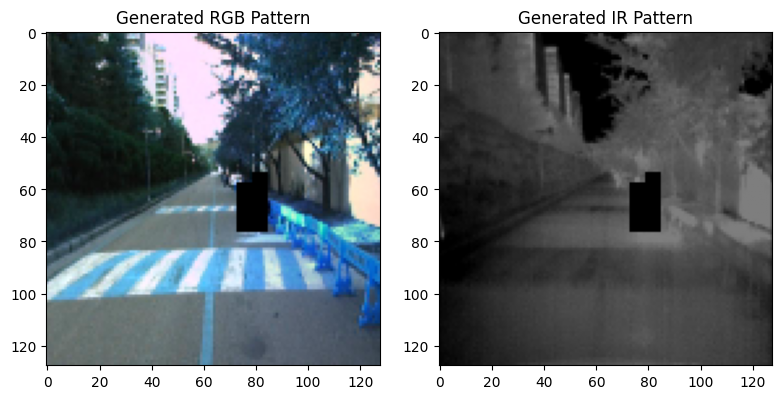

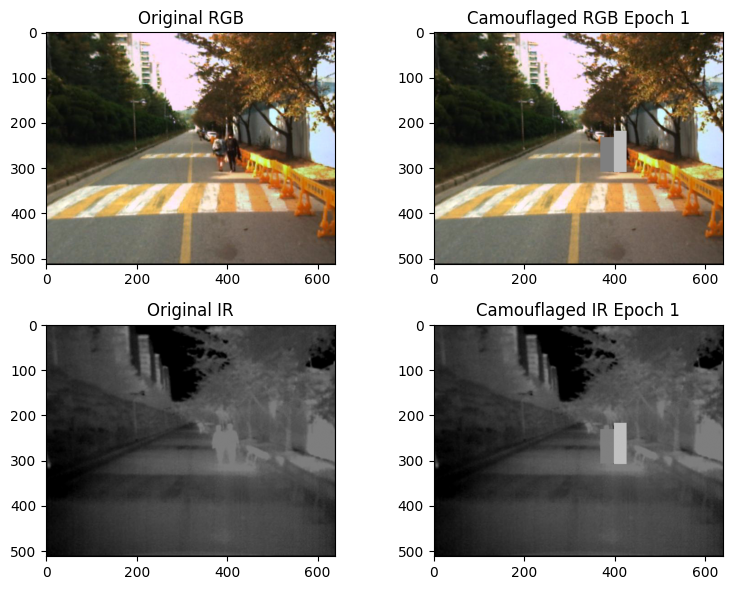

Epoch 2/3: 100%|██████████| 417/417 [15:15<00:00,  2.20s/it, G=12.184, Det=0.397, D_RGB=0.098, D_IR=0.010, BG_RGB=0.013, BG_IR=0.015, Thermal=0.010]


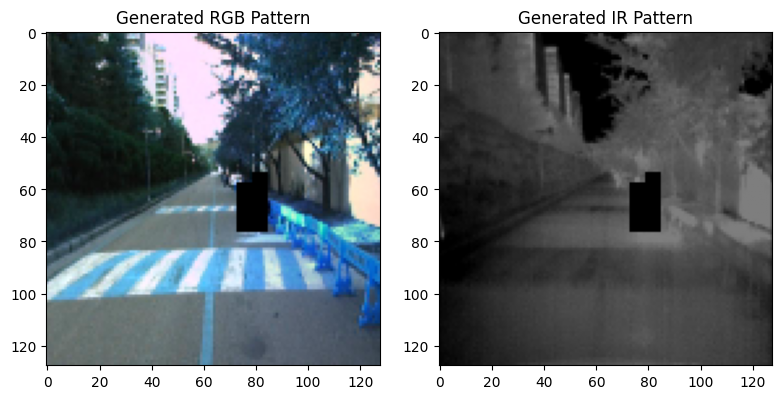

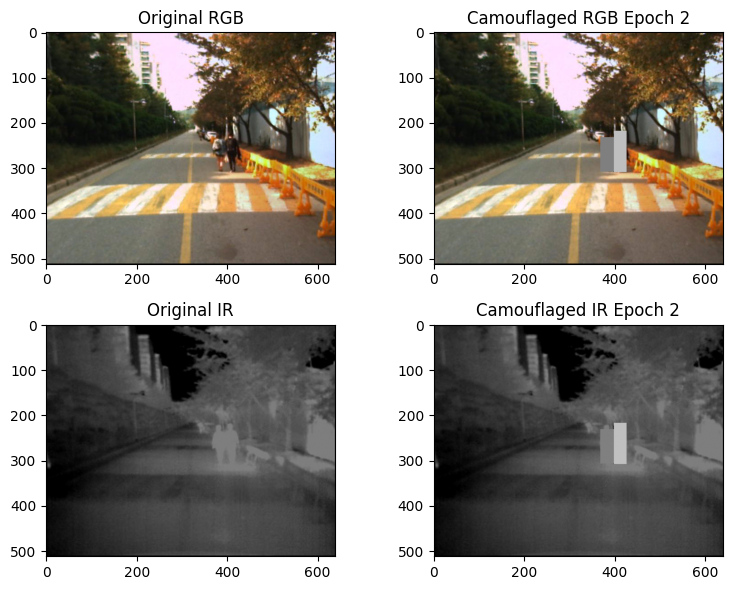

Epoch 3/3: 100%|██████████| 417/417 [15:01<00:00,  2.16s/it, G=15.639, Det=0.396, D_RGB=0.097, D_IR=0.005, BG_RGB=0.013, BG_IR=0.013, Thermal=0.008]


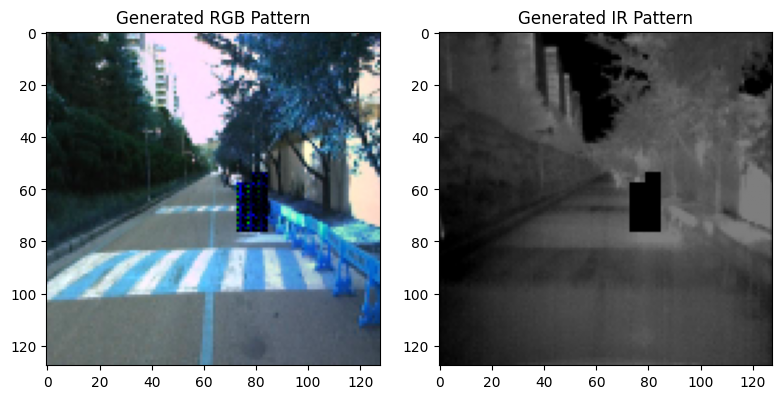

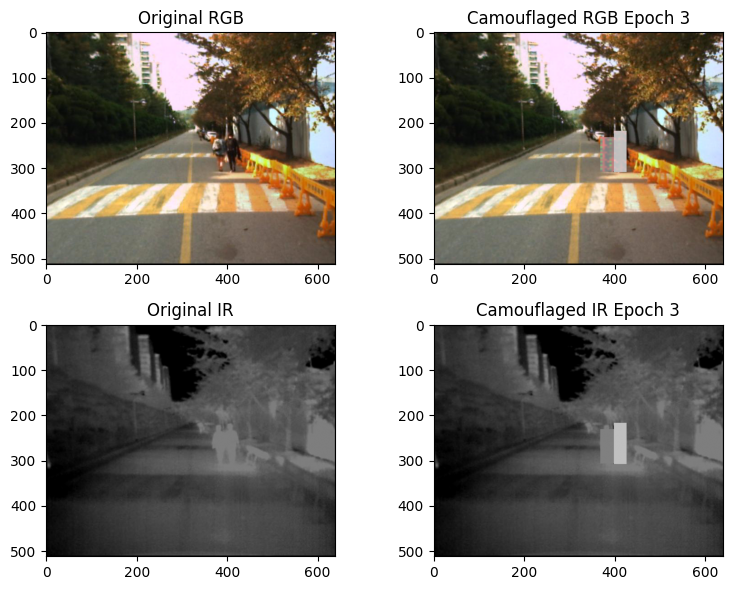

In [ ]:
epochs = 3

for epoch in range(epochs):

    pbar = tqdm(
        loader,
        desc=f"Epoch {epoch+1}/{epochs}"
    )

    for batch in pbar:

        (
            contexts,
            all_rgb_targets,
            all_ir_targets
        ) = prepare_batch_targets(
            batch,
            device
        )

        bs = contexts.shape[0]

        all_boxes = []

        for item in batch:
          all_boxes.append(item[5])

        # Extract rgb and ir from the batch, resize to 128x128, and stack them
        batch_rgb_imgs = []
        batch_ir_imgs = []
        for item in batch:
            # The 4th and 5th elements in the dataset item are rgb and ir images (numpy arrays)
            # Resize and convert to tensor, then permute to C,H,W
            rgb_original = item[3]
            ir_original = item[4]

            H, W = rgb_original.shape[:2]

            rgb_img = cv2.resize(rgb_original, (128, 128))
            ir_img = cv2.resize(ir_original, (128, 128))

            rgb_tensor = torch.tensor(rgb_img, dtype=torch.float32).permute(2, 0, 1)
            ir_tensor = torch.tensor(ir_img, dtype=torch.float32).unsqueeze(0) # Add channel dim for IR

            batch_rgb_imgs.append(rgb_tensor)
            batch_ir_imgs.append(ir_tensor)

        rgb = torch.stack(batch_rgb_imgs)
        ir = torch.stack(batch_ir_imgs)

        # Normalize to [-1, 1]
        rgb = rgb.float() / 127.5 - 1
        ir = ir.float() / 127.5 - 1

        # Ensure IR has a channel dimension (already handled by unsqueeze above, but keeping for safety/clarity)
        if ir.ndim == 3: # If it somehow became (B, H, W) again
          ir = ir.unsqueeze(1)

        mask = torch.zeros(
            rgb.size(0),
            1,
            rgb.size(2),
            rgb.size(3),
            device=rgb.device
        )

        for b_idx in range(rgb.size(0)):

            H, W = batch[b_idx][3].shape[:2]
            sx = 128/W
            sy = 128/H

            for box in all_boxes[b_idx]:

                x1, y1, x2, y2 = box
                x1 = int(x1 * sx)
                y1 = int(y1 * sy)
                x2 = int(x2 * sx)
                y2 = int(y2 * sy)

                mask[b_idx, :, y1:y2, x1:x2] = 1.0

        inp = torch.cat([rgb, ir, mask], dim=1).to(device)

        # The RuntimeError is fixed by passing 4D tensors to avg_pool2d. The prepare_target functions now return 3D tensors, which are stacked into a 4D batch in prepare_batch_targets.
        # The issue was that the `all_rgb_targets` and `all_ir_targets` were 5D, likely due to an accidental extra unsqueeze or a missing squeeze during batching.
        # With the `.squeeze(0)` additions to `prepare_rgb_target` and `prepare_ir_target`, the output of `torch.stack` in `prepare_batch_targets` should now be 4D.
        all_rgb_targets = nnF.avg_pool2d(
            all_rgb_targets,
            kernel_size=7,
            stride=1,
            padding=3
        )

        all_ir_targets = nnF.avg_pool2d(
            all_ir_targets,
            kernel_size=7,
            stride=1,
            padding=3
        )

        fake_rgb, fake_ir = G(
            inp,
            contexts,
            all_rgb_targets,
            all_ir_targets
        )

        '''# DEBUG
        if pbar.n % 100 == 0:
            print(
                "fake_rgb:",
                fake_rgb.min().item(),
                fake_rgb.max().item(),
                fake_rgb.mean().item()
            )

            print(
                "fake_ir:",
                fake_ir.min().item(),
                fake_ir.max().item(),
                fake_ir.mean().item()
            )'''

        g_det = compute_detector_loss(
            batch,
            fake_rgb,
            fake_ir
        )

        #DEBUG
        optimizer_G.zero_grad()

        '''if pbar.n % 100 == 0:
          print(
              "Detector grad:",
              G.rgb_head.weight.grad.abs().mean().item()
          )'''
        #DEBUG END

        fake_rgb_loss = (fake_rgb + 1) / 2
        fake_ir_loss = (fake_ir + 1) / 2

        d_rgb_loss = train_rgb_discriminator(
            fake_rgb_loss,
            all_rgb_targets,
            D_rgb,
            optimizer_D_rgb
        )

        d_ir_loss = train_ir_discriminator(
            fake_ir_loss,
            all_ir_targets,
            D_ir,
            optimizer_D_ir
        )

        '''if pbar.n % 50 == 0:
          with torch.no_grad():

              print(
                  "D_RGB(real)=",
                  D_rgb(all_rgb_targets).mean().item()
              )

              print(
                  "D_RGB(fake)=",
                  D_rgb(fake_rgb_loss).mean().item()
              )

              print(
                  "D_IR(real)=",
                  D_ir(all_ir_targets).mean().item()
              )

              print(
                  "D_IR(fake)=",
                  D_ir(fake_ir_loss).mean().item()
              )'''

        (
            g_loss,
            bg_loss_rgb,
            bg_loss_ir,
            thermal_consistency_loss
        ) = compute_generator_loss(
            fake_rgb,
            fake_ir,
            all_rgb_targets,
            all_ir_targets,
            g_det,
            mask
        )

        g_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            G.parameters(),
            max_norm=1.0
        )

        grad_sum = 0

        '''# DEBUG
        for p in G.parameters():
            if p.grad is not None:
                grad_sum += p.grad.abs().mean().item()

        if pbar.n % 100 == 0:
          print("Generator grad:", grad_sum)
        #DEBUG END'''

        optimizer_G.step()

        pbar.set_postfix({
            "G": f"{g_loss.item():.3f}",
            "Det": f"{g_det.item():.3f}",
            "D_RGB": f"{d_rgb_loss.item():.3f}",
            "D_IR": f"{d_ir_loss.item():.3f}",
            "BG_RGB": f"{bg_loss_rgb.item():.3f}",
            "BG_IR": f"{bg_loss_ir.item():.3f}",
            "Thermal": f"{thermal_consistency_loss.item():.3f}"
        })

    '''print(
          f"AdvRGB     = {g_adv_rgb.item():.3f}\n"
          f"AdvIR      = {g_adv_ir.item():.3f}\n"
          f"BG_RGB     = {(bg_loss_rgb).item():.3f}\n"
          f"BG_IR      = {(bg_loss_ir).item():.3f}\n"
          f"Thermal    = {(0.2*thermal_consistency_loss).item():.3f}\n"
          f"Smooth     = {(0.1*g_smooth).item():.3f}\n"
      )'''

    visualize_epoch(
        epoch,
        G,
        fixed_context,
        fixed_rgb,
        fixed_ir,
        fixed_boxes,
        fixed_bg_targets,
        fixed_ir_targets,
        device
    )

In [ ]:
del G
del D_rgb
del D_ir

del optimizer_G
del optimizer_D_rgb
del optimizer_D_ir

#gc.collect()
torch.cuda.empty_cache()

# EDA

In [ ]:
# Collect a sample of image paths
sample_size = 1000
visible_paths_sample = random.sample(visible_paths, sample_size)

images_with_peds = []
images_without_peds = []

print(f"Processing {sample_size} images to classify pedestrians...")
for img_path in tqdm(visible_paths_sample, desc="Classifying images"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Resize for detection (as done in process_sample function)
    det_h, det_w = 384, 640
    img_small = cv2.resize(img, (det_w, det_h))

    boxes = detect_pedestrians_ensemble(img_small)

    if boxes:
        images_with_peds.append(img_path)
    else:
        images_without_peds.append(img_path)

print(f"Found {len(images_with_peds)} images with pedestrians and {len(images_without_peds)} without.")
'''
# Plotting images
def plot_sample_images(image_paths, title, num_to_plot=3):
    plt.figure(figsize=(15, 5))
    plt.suptitle(title, fontsize=16)
    for i, path in enumerate(random.sample(image_paths, min(num_to_plot, len(image_paths)))):
        img = cv2.imread(path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(1, num_to_plot, i + 1)
            plt.imshow(img_rgb)
            plt.title(os.path.basename(path))
            plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plot images with pedestrians
if images_with_peds:
    plot_sample_images(images_with_peds, "Sample Images With Pedestrians")
else:
    print("No images with pedestrians found in the sample.")

# Plot images without pedestrians
if images_without_peds:
    plot_sample_images(images_without_peds, "Sample Images Without Pedestrians")
else:
    print("No images without pedestrians found in the sample.")'''

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = [len(images_with_peds), len(images_without_peds)]
labels = ['With Pedestrians', 'Without Pedestrians']

fig = plt.figure(figsize=(8, 6))
sns.barplot(x=labels, y=counts, hue=labels, palette=['blue', 'red'], legend=False)
plt.title('Distribution of Images: With vs. Without Pedestrians')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import cv2
import random

# Ensure `detect_pedestrians_ensemble` and `visible_paths_sample` are available.
# If `visible_paths_sample` is not defined or is empty, re-sample 1000 images.
if 'visible_paths_sample' not in locals() or not visible_paths_sample or len(visible_paths_sample) != 1000:
    sample_size = 1000
    print(f"'visible_paths_sample' not found, empty, or not of size {sample_size}. Re-sampling...")
    # Assuming 'visible_paths' is defined from earlier cells
    visible_paths_sample = random.sample(visible_paths, sample_size)

all_pedestrian_widths = []
all_pedestrian_heights = []
all_pedestrian_areas = []

print(f"Detecting pedestrians and collecting bounding box dimensions for {len(visible_paths_sample)} images...")
for img_path in tqdm(visible_paths_sample, desc="Collecting dimensions"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Resize for detection (as done in detect_pedestrians_ensemble)
    det_h, det_w = 384, 640
    img_small = cv2.resize(img, (det_w, det_h))

    boxes = detect_pedestrians_ensemble(img_small)

    for box in boxes:
        # Box format: [x1, y1, x2, y2, conf]
        x1, y1, x2, y2 = box[0], box[1], box[2], box[3]
        width = x2 - x1
        height = y2 - y1
        area = width * height

        all_pedestrian_widths.append(width)
        all_pedestrian_heights.append(height)
        all_pedestrian_areas.append(area)

print(f"Collected {len(all_pedestrian_widths)} pedestrian bounding box dimensions.")

if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Distribution of Pedestrian Bounding Box Dimensions (from 1000-image sample)', fontsize=16)

    # Histogram for Width
    axes[0].hist(all_pedestrian_widths, bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Widths')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(axis='y', alpha=0.75)

    # Histogram for Height
    axes[1].hist(all_pedestrian_heights, bins=50, color='lightcoral', edgecolor='black')
    axes[1].set_title('Heights')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(axis='y', alpha=0.75)

    # Histogram for Area
    axes[2].hist(all_pedestrian_areas, bins=50, color='lightgreen', edgecolor='black')
    axes[2].set_title('Areas')
    axes[2].set_xlabel('Area (pixels^2)')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(axis='y', alpha=0.75)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("No pedestrian bounding boxes were detected in the sample to create histograms.")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for easier plotting, ensuring data exists
if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    df_dims = pd.DataFrame({
        'Width': all_pedestrian_widths,
        'Height': all_pedestrian_heights,
        'Area': all_pedestrian_areas
    })

    # Create a single figure with three subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Adjust figsize as needed
    fig.suptitle('Distribution of Pedestrian Bounding Box Dimensions', fontsize=16)

    # Box Plot for Width
    sns.boxplot(y=df_dims['Width'], color='skyblue', ax=axes[0])
    axes[0].set_title('Widths')
    axes[0].set_xlabel('Width (pixels)') # Changed to xlabel since y is now the dimension
    axes[0].set_ylabel('') # Clear y-label for consistency, or set a general one in suptitle
    axes[0].grid(axis='y', alpha=0.75)

    # Box Plot for Height
    sns.boxplot(y=df_dims['Height'], color='lightcoral', ax=axes[1])
    axes[1].set_title('Heights')
    axes[1].set_xlabel('Height (pixels)') # Changed to xlabel
    axes[1].set_ylabel('')
    axes[1].grid(axis='y', alpha=0.75)

    # Box Plot for Area
    sns.boxplot(y=df_dims['Area'], color='lightgreen', ax=axes[2])
    axes[2].set_title('Areas')
    axes[2].set_xlabel('Area (pixels^2)') # Changed to xlabel
    axes[2].set_ylabel('')
    axes[2].grid(axis='y', alpha=0.75)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("Not enough data collected for bounding box dimensions to create box plots.")

In [ ]:
if all_pedestrian_widths and all_pedestrian_heights and all_pedestrian_areas:
    mean_width = np.mean(all_pedestrian_widths)
    mean_height = np.mean(all_pedestrian_heights)
    mean_area = np.mean(all_pedestrian_areas)

    print(f"Mean Pedestrian Bounding Box Width: {mean_width:.2f} pixels")
    print(f"Mean Pedestrian Bounding Box Height: {mean_height:.2f} pixels")
    print(f"Mean Pedestrian Bounding Box Area: {mean_area:.2f} pixels^2")
else:
    print("No pedestrian bounding box data available to calculate mean dimensions.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.cluster import KMeans
from tqdm import tqdm

# Create a mapping from visible path to LWIR path
rgb_to_ir_map = {rgb_path.replace('/visible/', '/'): ir_path.replace('/lwir/', '/') for rgb_path, ir_path in zip(visible_paths, lwir_paths)}

# Filter for common keys (images present in both modalities)
common_keys = sorted(list(set(p.replace('/visible/', '/') for p in visible_paths).intersection(set(p.replace('/lwir/', '/') for p in lwir_paths))))

# Reconstruct the paired lists using only common keys
visible_paths_filtered = [os.path.join(os.path.dirname(key), 'visible', os.path.basename(key)) for key in common_keys]
lwir_paths_filtered = [os.path.join(os.path.dirname(key), 'lwir', os.path.basename(key)) for key in common_keys]

# Recreate the map from the filtered paths to ensure only paired images are used
rgb_to_ir_map_filtered = {rgb_path: ir_path for rgb_path, ir_path in zip(visible_paths_filtered, lwir_paths_filtered)}

print(f"Created a mapping of {len(rgb_to_ir_map_filtered)} paired image paths.")

In [ ]:
def get_masked_background_and_features(rgb_image_path, ir_image_path, k=3):
    rgb_img = cv2.imread(rgb_image_path)
    ir_img = cv2.imread(ir_image_path, cv2.IMREAD_GRAYSCALE)

    if rgb_img is None or ir_img is None:
        return None, None, None, None, None

    original_h, original_w, _ = rgb_img.shape

    # Resize for detection
    det_h, det_w = 384, 640 # Consistent with previous detection cells
    rgb_small = cv2.resize(rgb_img, (det_w, det_h))

    # Detect pedestrians
    boxes = detect_pedestrians_ensemble(rgb_small)

    # Scale boxes back to original image dimensions
    scaled_boxes = []
    sx = original_w / det_w
    sy = original_h / det_h
    for box in boxes:
        x1, y1, x2, y2, conf = box
        scaled_boxes.append([
            int(x1 * sx),
            int(y1 * sy),
            int(x2 * sx),
            int(y2 * sy),
            conf
        ])

    # Create a mask for all detected pedestrians
    mask = np.ones(rgb_img.shape[:2], dtype=np.uint8) * 255 # White mask for background
    if scaled_boxes:
        for x1, y1, x2, y2, _ in scaled_boxes:
            # Ensure coordinates are within image bounds
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(original_w, x2)
            y2 = min(original_h, y2)
            cv2.rectangle(mask, (x1, y1), (x2, y2), 0, -1) # Black out pedestrian regions

    # Apply mask to get background
    rgb_background_masked = rgb_img.copy()
    ir_background_masked = ir_img.copy()

    # Create a 3-channel mask for RGB to handle cases where background should be black
    rgb_mask_3_channel = np.stack([mask, mask, mask], axis=-1)
    rgb_background_masked[rgb_mask_3_channel == 0] = 0 # Set masked areas to black

    ir_background_masked[mask == 0] = 0 # Set masked areas to black

    # Extract pixels for KMeans and IR statistics
    pixels_for_kmeans = rgb_background_masked.reshape(-1, 3)
    pixels_for_kmeans = pixels_for_kmeans[np.any(pixels_for_kmeans != 0, axis=1)] # Only non-black pixels

    ir_pixels = ir_background_masked.flatten()
    ir_pixels = ir_pixels[ir_pixels != 0] # Only non-black pixels

    dominant_colours = None
    if len(pixels_for_kmeans) > 0:
        kmeans = KMeans(n_clusters=min(k, len(pixels_for_kmeans)), random_state=0, n_init='auto')
        kmeans.fit(pixels_for_kmeans)
        dominant_colours = kmeans.cluster_centers_

    return rgb_background_masked, ir_background_masked, dominant_colours, ir_pixels, k

### Collecting background features from 1000 sample images

In [ ]:
all_rgb_backgrounds_for_analysis = []
all_ir_pixels_data = []

print(f"Extracting background features from {len(training_data)} samples in training_data...")

# Iterate through training_data to extract rgb_bg_targets and ir_bg_targets
for sample_data in tqdm(training_data, desc="Extracting background features from training_data"):
    # training_data structure: (scene_context, rgb_bg_targets, ir_bg_targets, rgb, ir, all_boxes, rgb_path, ir_path)
    # We are interested in rgb_bg_targets (index 1) and ir_bg_targets (index 2)
    _, rgb_bg_targets_list, ir_bg_targets_list, _, _, _, _, _ = sample_data

    for rgb_patch in rgb_bg_targets_list:
        if rgb_patch is not None and rgb_patch.size > 0:
            all_rgb_backgrounds_for_analysis.append(rgb_patch)

    for ir_patch in ir_bg_targets_list:
        if ir_patch is not None and ir_patch.size > 0:
            all_ir_pixels_data.extend(ir_patch.flatten()) # Flatten and extend all IR pixels

print(f"Collected background features from {len(all_rgb_backgrounds_for_analysis)} RGB patches and {len(all_ir_pixels_data)} IR pixels.")

### 1. Dominant Colours in Background

In [ ]:
# Aggregate all dominant colors and re-run KMeans for overall dominant colors
if all_dominant_colours_list:
    # Use the collected dominant colors or directly aggregate all non-zero pixels
    # For better representation, let's aggregate all non-zero RGB pixels from all backgrounds
    all_non_zero_rgb_pixels = np.vstack([bg[np.any(bg != 0, axis=2)] for bg in all_rgb_backgrounds_for_analysis if bg.size > 0])

    if len(all_non_zero_rgb_pixels) > 0:
        k = 5 # Number of overall dominant colors
        kmeans_overall = KMeans(n_clusters=min(k, len(all_non_zero_rgb_pixels)), random_state=0, n_init='auto')
        kmeans_overall.fit(all_non_zero_rgb_pixels)
        overall_dominant_colours = kmeans_overall.cluster_centers_

        print("### Overall Dominant Colours in Background")
        print("The overall dominant colors in the RGB background are:")
        for i, color in enumerate(overall_dominant_colours):
            print(f"Color {i+1}: RGB({color[0]:.2f}, {color[1]:.2f}, {color[2]:.2f})")

        plt.figure(figsize=(8, 2))
        for i, color in enumerate(overall_dominant_colours):
            plt.subplot(1, len(overall_dominant_colours), i + 1)
            plt.imshow([[color.astype(np.uint8)]])
            plt.axis("off")
        plt.suptitle("Overall Dominant Colors in Background")
        plt.show()
    else:
        print("No non-zero RGB pixels found in backgrounds to determine dominant colors.")
else:
    print("No dominant colors collected from the sample for background analysis.")

print("\n" + "-" * 50 + "\n")

### 2. Colour Distribution in Background

In [ ]:
print("### Colour Distribution in Background")

if all_rgb_backgrounds_for_analysis:
    # Concatenate all RGB background pixels (excluding black masked areas) for a global histogram
    global_rgb_background_pixels = np.vstack([bg[np.any(bg != 0, axis=2)] for bg in all_rgb_backgrounds_for_analysis if bg.size > 0])

    if global_rgb_background_pixels.size > 0:
        plt.figure(figsize=(15, 5))
        colors = ('b', 'g', 'r')
        titles = ('Blue Channel Distribution', 'Green Channel Distribution', 'Red Channel Distribution')

        for i, col in enumerate(colors):
            plt.subplot(1, 3, i + 1)
            # Calculate histogram for each channel separately
            # Corrected: Pass the specific channel as a single-channel array
            hist = cv2.calcHist([global_rgb_background_pixels[:, i]], [0], None, [256], [0, 256])
            plt.plot(hist, color=col)
            plt.xlim([0, 256])
            plt.title(titles[i])
            plt.xlabel('Pixel Intensity')
            plt.ylabel('Frequency')
        plt.suptitle('Aggregated RGB Background Colour Distribution')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print("No non-zero RGB pixels found in aggregated backgrounds to plot color distribution.")
else:
    print("No RGB background data available for color distribution analysis.")

print("\n" + "-" * 50 + "\n")

### 3. Texture Statistics

In [ ]:
print("### Texture Statistics")

# For IR background
if all_ir_pixels_data:
    aggregated_ir_pixels = np.array(all_ir_pixels_data)
    print("\nAggregated IR Background Thermal Intensity Statistics:")
    print(f"  Mean: {np.mean(aggregated_ir_pixels):.2f}")
    print(f"  Standard Deviation: {np.std(aggregated_ir_pixels):.2f}")
    print(f"  Min: {np.min(aggregated_ir_pixels):.2f}")
    print(f"  Max: {np.max(aggregated_ir_pixels):.2f}")

    # Histogram for thermal intensity
    plt.figure(figsize=(8, 5))
    plt.hist(aggregated_ir_pixels, bins=50, color='orange', edgecolor='black')
    plt.title('Aggregated IR Background Thermal Intensity Histogram')
    plt.xlabel('Thermal Intensity (Pixel Value)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

else:
    print("No IR background pixel data available for thermal intensity statistics.")

# For RGB background (using Sobel for texture)
if all_rgb_backgrounds_for_analysis:
    all_mean_gradient_magnitudes = []
    all_std_gradient_magnitudes = []

    for bg_img in all_rgb_backgrounds_for_analysis:
        if bg_img.size > 0:
            try:
                # Convert to grayscale, handling potential 2D images if somehow passed
                if len(bg_img.shape) == 3:
                    bg_img_gray = cv2.cvtColor(bg_img, cv2.COLOR_RGB2GRAY)
                else:
                    bg_img_gray = bg_img # Already grayscale

                # Ensure background is not entirely black (masked out)
                if np.sum(bg_img_gray) > 0:
                    # Re-using the extract_texture_features function
                    rgb_texture_features = extract_texture_features(bg_img) # The function expects RGB, it converts to gray internally
                    all_mean_gradient_magnitudes.append(rgb_texture_features[0])
                    all_std_gradient_magnitudes.append(rgb_texture_features[1])
            except Exception as e:
                print(f"Error processing RGB background for texture: {e}")

    if all_mean_gradient_magnitudes:
        print("\nAggregated RGB Background Texture Statistics (Sobel Magnitude):")
        print(f"  Average Mean Gradient Magnitude: {np.mean(all_mean_gradient_magnitudes):.2f}")
        print(f"  Average Std Dev Gradient Magnitude: {np.mean(all_std_gradient_magnitudes):.2f}")
    else:
        print("No valid RGB background data found for texture analysis.")
else:
    print("No RGB background data available for texture analysis.")

print("\n" + "-" * 50 + "\n")

### 4. Background Diversity

In [ ]:
print("### Background Diversity")

# Number of dominant colors is implicitly handled by the k-value in KMeans
print(f"Number of clusters used for overall dominant colors: {k}")

# Diversity based on standard deviation of pixel intensities
if all_rgb_backgrounds_for_analysis:
    # Concatenate all non-zero RGB background pixels
    global_rgb_background_pixels_diversity = np.vstack([bg[np.any(bg != 0, axis=2)] for bg in all_rgb_backgrounds_for_analysis if bg.size > 0])
    if global_rgb_background_pixels_diversity.size > 0:
        rgb_std_dev = np.std(global_rgb_background_pixels_diversity)
        print(f"Aggregated Standard Deviation of RGB background pixel intensities: {rgb_std_dev:.2f}")
    else:
        print("No non-zero RGB pixels found in backgrounds to compute standard deviation.")
else:
    print("No RGB background data available to compute standard deviation.")

if all_ir_pixels_data:
    aggregated_ir_pixels_diversity = np.array(all_ir_pixels_data)
    if aggregated_ir_pixels_diversity.size > 0:
        ir_std_dev = np.std(aggregated_ir_pixels_diversity)
        print(f"Aggregated Standard Deviation of IR background pixel intensities: {ir_std_dev:.2f}")
    else:
        print("No non-zero IR pixels found in backgrounds to compute standard deviation.")
else:
    print("No IR background pixel data available to compute standard deviation.")

### 5. Detection Confidence and Number of Detections

In [ ]:
all_confidence_scores = []
num_detections_per_image = []

print(f"Analyzing detection confidence and number of detections for {len(visible_paths_sample)} images...")

for img_path in tqdm(images_with_peds, desc="Collecting detection data"):
    img = cv2.imread(img_path)
    if img is None:
        continue

    # Resize for detection (as done in process_sample function)
    det_h, det_w = 384, 640
    img_small = cv2.resize(img, (det_w, det_h))

    boxes = detect_pedestrians_ensemble(img_small)

    num_detections_per_image.append(len(boxes))

    for box in boxes:
        # Box format: [x1, y1, x2, y2, conf]
        all_confidence_scores.append(box[4])

print(f"Collected {len(all_confidence_scores)} confidence scores and {len(num_detections_per_image)} detection counts.")

In [ ]:
if all_confidence_scores:
    plt.figure(figsize=(10, 6))
    sns.histplot(all_confidence_scores, bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.title('Distribution of Pedestrian Detection Confidence Scores')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No confidence scores were collected to plot the distribution.")

In [ ]:
if num_detections_per_image:
    plt.figure(figsize=(10, 6))
    sns.histplot(num_detections_per_image, bins=range(max(num_detections_per_image) + 2), discrete=True, color='lightcoral', edgecolor='black')
    plt.title('Histogram of Number of Pedestrian Detections Per Image')
    plt.xlabel('Number of Detections')
    plt.ylabel('Frequency (Number of Images)')
    plt.xticks(range(max(num_detections_per_image) + 1))
    plt.grid(axis='y', alpha=0.75)
    plt.show()
else:
    print("No detection counts were collected to plot the histogram.")

In [ ]:
import sys
import pkg_resources

print(f"Python Version: {sys.version}\n")

# List of libraries to check (you might need to adjust this list based on what is actually imported)
# I'm inferring common libraries used in the notebook based on the provided context

libs_to_check = [
    'numpy',
    'matplotlib',
    'tensorflow',
    'torch',
    'torchvision',
    'ultralytics',
    'opencv-python',
    'scikit-learn', # For KMeans, which is sklearn.cluster.KMeans
    'seaborn',
    'pandas',
    'scikit-learn'
]

print("Library Versions:")
for lib_name in libs_to_check:
    try:
        # Some libraries have __version__, others require pkg_resources
        if hasattr(sys.modules.get(lib_name), '__version__'):
            version = sys.modules.get(lib_name).__version__
        else:
            version = pkg_resources.get_distribution(lib_name).version
        print(f"{lib_name}: {version}")
    except pkg_resources.DistributionNotFound:
        print(f"{lib_name}: Not Found (or not installed in this environment)")
    except Exception as e:
        print(f"{lib_name}: Error retrieving version - {e}")